In [108]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/ukb_targets")
library(data.table)
library(ggplot2)
library(ggrepel)

`geom_smooth()` using formula 'y ~ x'

Warning message:
"Removed 1699 rows containing missing values (geom_text_repel)."


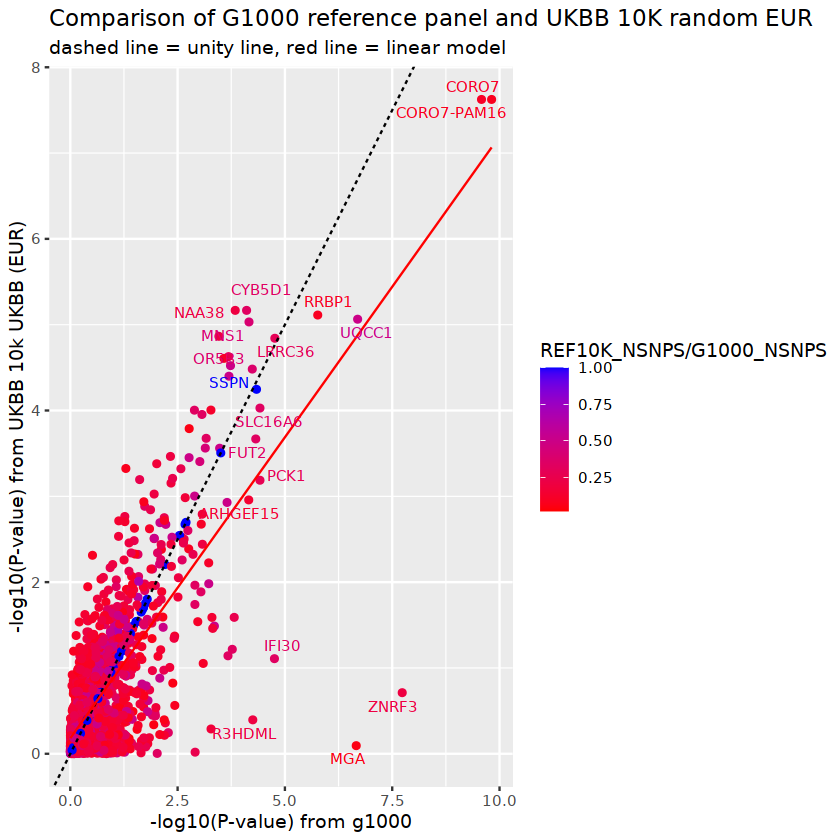

In [237]:
d1 <- fread('data/magma/WHRadjBMI_eur_add/WHRadjBMI_C_Eur_ADD.genes.txt')[,c('HGNC_SYMBOL','P','NSNPS')]
d2 <- fread('data/magma/WHRadjBMI_eur_add_ref10k/WHRadjBMI_C_Eur_ADD.txt')[,c('HGNC_SYMBOL', 'P','NSNPS')]
colnames(d1)[2:3] <- c('G1000_P','G1000_NSNPS') # g1000
colnames(d2)[2:3] <- c('REF10K_P','REF10K_NSNPS') # ref
mrg <- merge(d1, d2)
fit <- lm(-log10(G1000_P) ~ -log10(REF10K_P), data = mrg)
residuals <- fit$residuals
pass <- residuals > quantile(residuals, 0.99)
mrg$label <- NA
mrg$label[pass] <- mrg$HGNC_SYMBOL[pass]

#mrg <- mrg[mrg$REF10K_NSNPS/mrg$G1000_NSNPS > 0.6]
ggplot(mrg, aes(x=-log10(G1000_P), y=-log10(REF10K_P), label = label, color = REF10K_NSNPS/G1000_NSNPS)) +
    geom_point() +
    geom_abline(linetype = 'dashed') +
    geom_smooth(method='lm', se = FALSE, color = 'red', size = 0.5) +
    geom_text_repel(size = 3, max.overlaps = Inf) +
    scale_color_gradient(low = 'red', high = 'blue') +
    xlab('-log10(P-value) from g1000') +
    ylab('-log10(P-value) from UKBB 10k UKBB (EUR)') +
    ggtitle('Comparison of G1000 reference panel and UKBB 10K random EUR',
            'dashed line = unity line, red line = linear model')

In [221]:
head(mrg)

HGNC_SYMBOL,P1,NSNPS1,P2,NSNPS2,label
<chr>,<dbl>,<int>,<dbl>,<int>,<chr>
A2M,0.078817,6,0.040987,1,NA
A2ML1,0.247850,24,0.666550,2,NA
A4GALT,0.839130,2,0.571440,1,NA
AAMDC,0.581460,2,0.595560,1,NA
AARS,0.408720,11,0.570770,1,NA
AATF,0.208510,3,0.061297,1,NA


In [180]:
scale_color_gradient()

[1] -0.6931499
[1] -0.667323


In [217]:
d <- fread('data/magma/WHRadjBMI_eur_add/WHRadjBMI_C_Eur_ADD.genes.txt')
head(d)


GENE,CHR,START,STOP,NSNPS,NPARAM,N,ZSTAT,P,HGNC_SYMBOL,FDR
<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>
9031,7,72854728,72936628,8,4,276683,7.2886,1.5660e-13,BAZ1B,1.704591e-09
23166,3,52529354,52558512,20,14,245915,7.1099,5.8081e-13,STAB1,3.161058e-09
10144,4,89647105,90032549,10,6,274734,6.9170,2.3065e-12,FAM13A,8.368751e-09
8200,20,34021149,34026027,5,2,253372,6.5535,2.8103e-11,GDF5,7.647529e-08
100529144,16,4390252,4466962,13,9,246919,6.2958,1.5294e-10,CORO7-PAM16,3.329504e-07
79585,16,4404543,4466962,10,7,252457,6.2113,2.6278e-10,CORO7,4.767267e-07


In [73]:
d$START <- NULL
d$STOP <- NULL

In [74]:
# get GTex and merge
gtex <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/gtex/GTEx.tstat.tsv')
colnames(gtex) <- gsub('(\\()|(\\))','',colnames(gtex))
bridge <- fread('/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/protein_coding_genes.tsv')[,1:2]
colnames(bridge) <- c('ENSGID','HGNC_SYMBOL')
gtex <- merge(bridge, gtex[,1:3], all.y = TRUE)

In [75]:
tissue_specific <- as.data.table(lapply(gtex[,3:4], function(x) x > quantile(x, 0.9)))
colnames(tissue_specific) <- paste0(colnames(tissue_specific), '_specific')
gtex <- cbind(
    gtex,
    tissue_specific
)

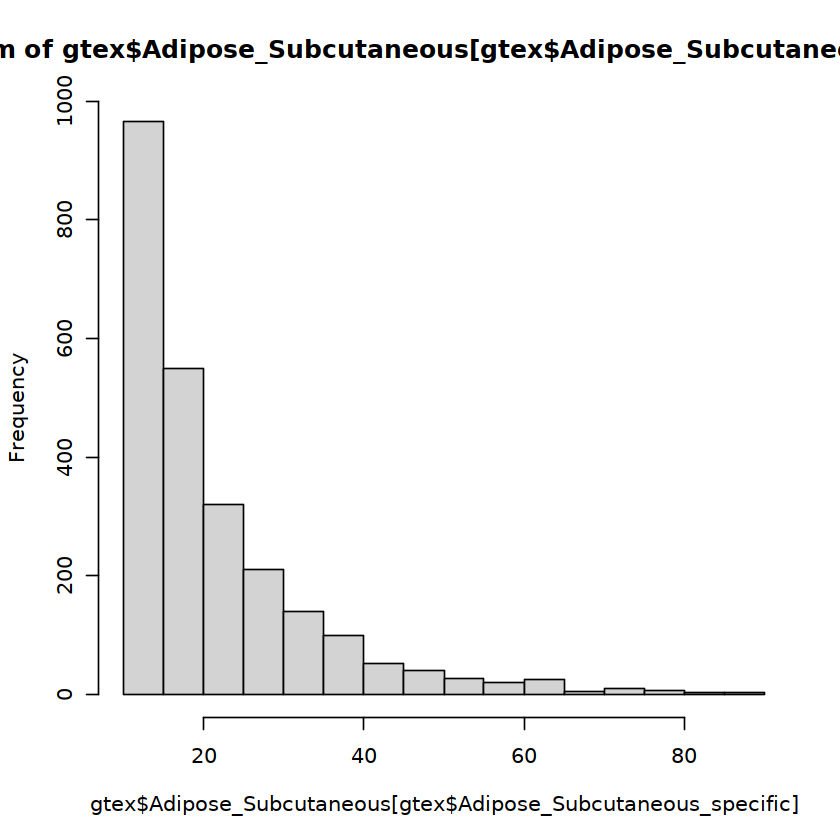

In [76]:
hist(gtex$Adipose_Subcutaneous[gtex$Adipose_Subcutaneous_specific])

In [145]:
magma <- merge(d, gtex, by = 'HGNC_SYMBOL')
magma <- magma[order(magma$P),]
magma$label <- NA

Warning message:
"Removed 978 rows containing missing values (geom_text_repel)."
Warning message:
"ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


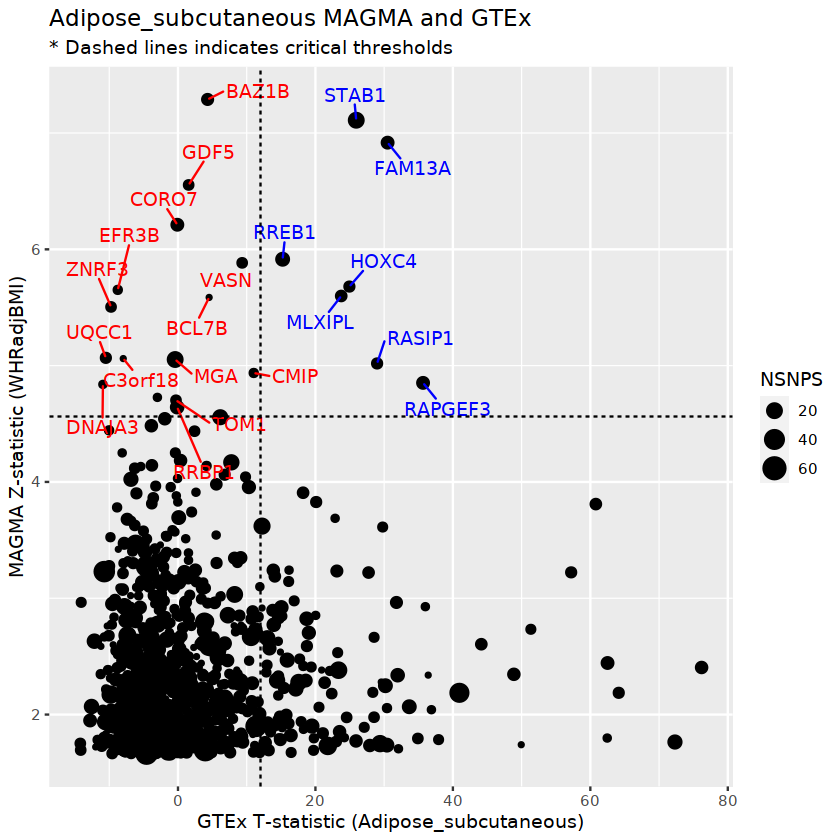

In [215]:
# get critical thresholds
alpha <- 0.05 / nrow(magma)
magma_zstat_crit <- qnorm(1-(alpha/2))
gtex_quantile <- quantile(magma$Adipose_Subcutaneous, 0.9)

# setup what genes are passing each
passing_gtex <- magma$Adipose_Subcutaneous >= gtex_quantile
passing_magma <- (magma$ZSTAT >= magma_zstat_crit)

# label accordingly
magma$label[passing_magma] <- magma$HGNC_SYMBOL[passing_magma]
magma$colors[passing_magma] <- 'red'
magma$colors[passing_magma & passing_gtex] <- 'blue'

# plot resulting
dtmp <- head(magma, 1000)
ggplot(dtmp, aes(y=ZSTAT, x=Adipose_Subcutaneous, size = NSNPS, label = label, max.overlaps = Inf)) +
    geom_point() +
    geom_text_repel(size = 4, color = dtmp$color, box.padding = 0.7) + 
    geom_hline(yintercept = magma_zstat_crit, linetype = 'dashed') +
    geom_vline(xintercept = gtex_quantile, linetype = 'dashed') +
    xlab("GTEx T-statistic (Adipose_subcutaneous)") +
    ylab("MAGMA Z-statistic (WHRadjBMI)") +
    ggtitle('Adipose_subcutaneous MAGMA and GTEx', "* Dashed lines indicates critical thresholds")

Warning message:
"Removed 978 rows containing missing values (geom_text_repel)."


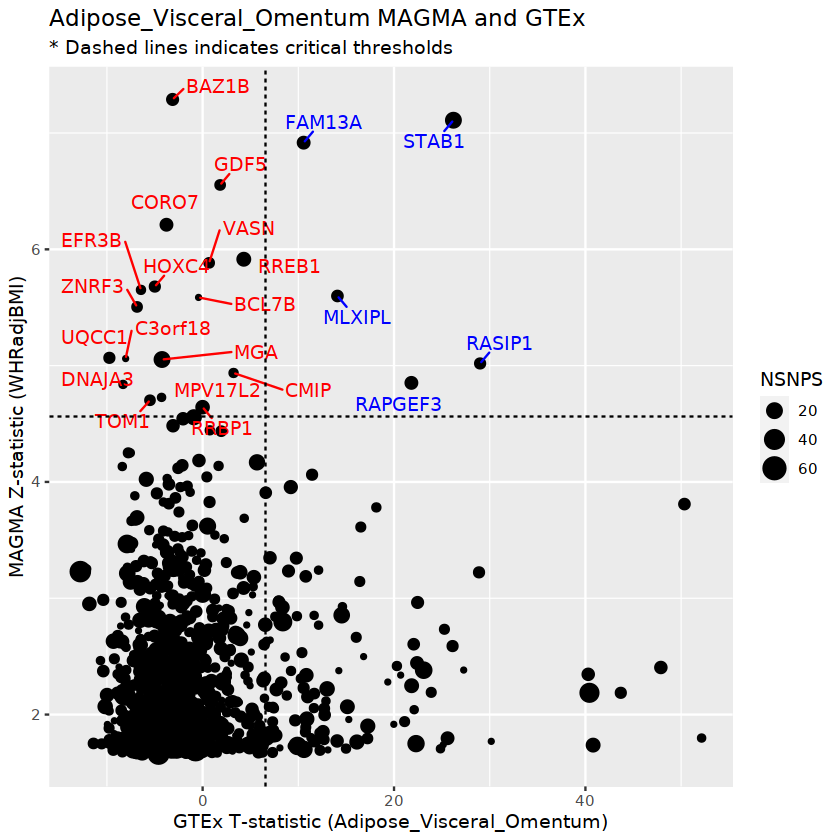

In [162]:
# get critical thresholds
alpha <- 0.05 / nrow(magma)
magma_zstat_crit <- qnorm(1-(alpha/2))
gtex_quantile <- quantile(magma$Adipose_Visceral_Omentum, 0.9)

# setup what genes are passing each
passing_gtex <- magma$Adipose_Visceral_Omentum >= gtex_quantile
passing_magma <- (magma$ZSTAT >= magma_zstat_crit)

# label accordingly
magma$label[passing_magma] <- magma$HGNC_SYMBOL[passing_magma]
magma$colors[passing_magma] <- 'red'
magma$colors[passing_magma & passing_gtex] <- 'blue'

# plot resulting
dtmp <- head(magma, 1000)
ggplot(dtmp, aes(y=ZSTAT, x=Adipose_Visceral_Omentum, size = NSNPS, label = label)) +
    geom_point() +
    geom_text_repel(size = 4, color = dtmp$color, box.padding = 0.5, max.overlaps = Inf) + 
    geom_hline(yintercept = magma_zstat_crit, linetype = 'dashed') +
    geom_vline(xintercept = gtex_quantile, linetype = 'dashed') +
    xlab("GTEx T-statistic (Adipose_Visceral_Omentum)") +
    ylab("MAGMA Z-statistic (WHRadjBMI)") +
    ggtitle('Adipose_Visceral_Omentum MAGMA and GTEx', "* Dashed lines indicates critical thresholds")